# Projeto final de PLN: avaliacoes Olist

Este notebook implementa um pipeline end-to-end simples para o trabalho final da disciplina de Processamento de Linguagem Natural.

Objetivo: transformar avaliacoes textuais da Olist em informacoes uteis por meio de pre-processamento, vetorizacao, busca por similaridade, classificacao, topicos, NER/termos de dominio e grafo de conhecimento.

## 1. Configuracao inicial

In [1]:
from pathlib import Path
from collections import Counter
import itertools
import re
import warnings

import joblib
import matplotlib.pyplot as plt
import networkx as nx
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
import spacy

from nltk.corpus import stopwords
from nltk.stem import RSLPStemmer
from nltk.tokenize import RegexpTokenizer
from sklearn.decomposition import NMF
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from wordcloud import WordCloud

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

RANDOM_STATE = 42
MAX_DOCS = 15000
NER_SAMPLE_SIZE = 1000

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_PATH = PROJECT_ROOT / 'Data' / 'olist_order_reviews_dataset.csv'
OUTPUTS_DIR = PROJECT_ROOT / 'outputs'
FIGURES_DIR = OUTPUTS_DIR / 'figures'
TABLES_DIR = OUTPUTS_DIR / 'tables'
MODELS_DIR = OUTPUTS_DIR / 'models'
GRAPHS_DIR = OUTPUTS_DIR / 'graphs'

for path in [FIGURES_DIR, TABLES_DIR, MODELS_DIR, GRAPHS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print(f'Projeto: {PROJECT_ROOT}')
print(f'Dataset: {DATA_PATH}')

Projeto: C:\Users\andrei.pereira\PNL_Infnet
Dataset: C:\Users\andrei.pereira\PNL_Infnet\Data\olist_order_reviews_dataset.csv


In [2]:
def garantir_recurso_nltk(nome, caminho):
    try:
        nltk.data.find(caminho)
    except LookupError:
        nltk.download(nome, quiet=True)


garantir_recurso_nltk('punkt', 'tokenizers/punkt')
garantir_recurso_nltk('punkt_tab', 'tokenizers/punkt_tab')
garantir_recurso_nltk('stopwords', 'corpora/stopwords')
garantir_recurso_nltk('rslp', 'stemmers/rslp')


def carregar_spacy_pt():
    try:
        return spacy.load('pt_core_news_sm', disable=['parser']), True
    except OSError:
        nlp_blank = spacy.blank('pt')
        if 'sentencizer' not in nlp_blank.pipe_names:
            nlp_blank.add_pipe('sentencizer')
        print('Modelo pt_core_news_sm nao encontrado. Execute: python -m spacy download pt_core_news_sm')
        print('O notebook seguira com spaCy blank, mas POS tagging, lematizacao e NER ficarao limitados.')
        return nlp_blank, False


nlp, SPACY_MODEL_OK = carregar_spacy_pt()
print('Pipeline spaCy:', nlp.pipe_names)

Pipeline spaCy: ['tok2vec', 'morphologizer', 'lemmatizer', 'attribute_ruler', 'ner']


## 2. Carregamento e caracterizacao inicial

In [3]:
df_raw = pd.read_csv(DATA_PATH)
df_raw.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [4]:
def rotular_score(score):
    if score <= 2:
        return 'negativo'
    if score == 3:
        return 'neutro'
    return 'positivo'


df = df_raw.copy()
df['review_comment_title'] = df['review_comment_title'].fillna('').astype(str)
df['review_comment_message'] = df['review_comment_message'].fillna('').astype(str)
df['texto'] = (df['review_comment_title'] + ' ' + df['review_comment_message']).str.strip()
df = df[df['texto'].str.len() > 0].copy()
df['sentimento'] = df['review_score'].apply(rotular_score)
df['review_creation_date'] = pd.to_datetime(df['review_creation_date'], errors='coerce')
df['n_chars'] = df['texto'].str.len()
df['n_palavras_brutas'] = df['texto'].str.split().str.len()

df_corpus_completo = df.reset_index(drop=True)
if len(df_corpus_completo) > MAX_DOCS:
    df = df_corpus_completo.sample(MAX_DOCS, random_state=RANDOM_STATE).sort_index().reset_index(drop=True)
else:
    df = df_corpus_completo.copy()

resumo = pd.DataFrame({
    'metrica': ['linhas_originais', 'avaliacoes_com_texto', 'documentos_usados_no_notebook'],
    'valor': [len(df_raw), len(df_corpus_completo), len(df)]
})
resumo.to_csv(TABLES_DIR / 'resumo_corpus.csv', index=False)
display(resumo)
display(df[['review_score', 'sentimento', 'texto', 'n_chars', 'n_palavras_brutas']].head())

,metrica,valor
0,linhas_originais,99224
1,avaliacoes_com_texto,42687
2,documentos_usados_no_notebook,15000


,review_score,sentimento,texto,n_chars,n_palavras_brutas
0,5,positivo,Recebi bem antes do prazo estipulado.,37,6
1,5,positivo,Parabéns lojas lannister adorei comprar pela I...,100,15
2,5,positivo,"Super recomendo Vendedor confiável, produto ok...",72,11
3,1,negativo,Não chegou meu produto Péssimo,31,5
4,5,positivo,Ótimo Loja nota 10,18,4


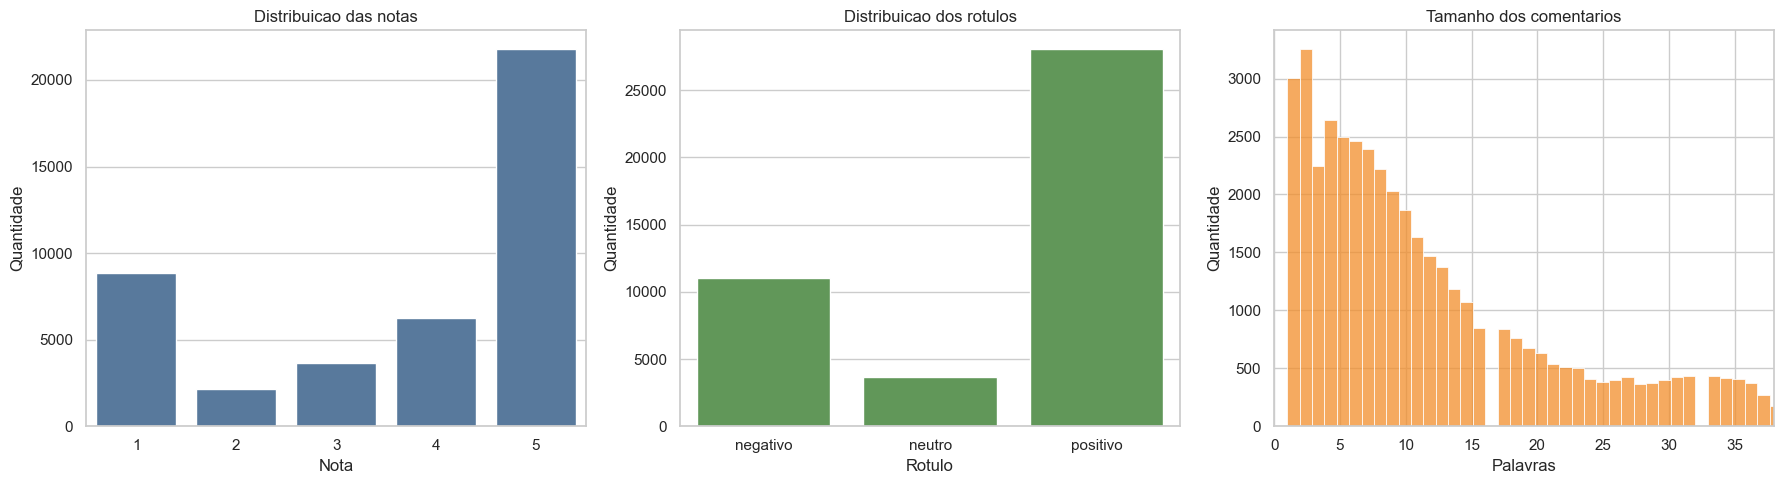

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=df_corpus_completo, x='review_score', ax=axes[0], color='#4C78A8')
axes[0].set_title('Distribuicao das notas')
axes[0].set_xlabel('Nota')
axes[0].set_ylabel('Quantidade')

sns.countplot(data=df_corpus_completo, x='sentimento', order=['negativo', 'neutro', 'positivo'], ax=axes[1], color='#59A14F')
axes[1].set_title('Distribuicao dos rotulos')
axes[1].set_xlabel('Rotulo')
axes[1].set_ylabel('Quantidade')

sns.histplot(df_corpus_completo['n_palavras_brutas'], bins=50, ax=axes[2], color='#F28E2B')
axes[2].set_title('Tamanho dos comentarios')
axes[2].set_xlabel('Palavras')
axes[2].set_ylabel('Quantidade')
axes[2].set_xlim(0, df_corpus_completo['n_palavras_brutas'].quantile(0.99))

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'eda_distribuicoes_iniciais.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Pre-processamento textual

Nesta etapa sao comparadas tres representacoes: tokens normalizados, stems e lemas. A representacao lematizada sera usada como texto principal dos modelos por ser mais interpretavel.

In [6]:
tokenizer = RegexpTokenizer(r'\b\w+\b')
stemmer = RSLPStemmer()

stopwords_pt = set(stopwords.words('portuguese'))
stopwords_custom = {'produto', 'pedido', 'compra', 'loja', 'cliente', 'vc', 'vcs', 'pra', 'pro', 'ta'}
stopwords_total = stopwords_pt.union(stopwords_custom)


def normalizar_texto(texto):
    texto = str(texto).lower()
    texto = re.sub(r'https?://\S+|www\.\S+', ' ', texto)
    texto = re.sub(r'\S+@\S+', ' ', texto)
    texto = re.sub(r'[^\w\s]', ' ', texto, flags=re.UNICODE)
    texto = re.sub(r'\d+', ' ', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto


def tokenizar(texto):
    return [token for token in tokenizer.tokenize(texto) if token.isalpha() and len(token) > 1]


def remover_stopwords(tokens):
    return [token for token in tokens if token not in stopwords_total]


def aplicar_stemming(tokens):
    return [stemmer.stem(token) for token in tokens]


def lematizar_textos(textos, batch_size=128):
    resultados = []
    for doc in nlp.pipe(textos, batch_size=batch_size):
        lemas = []
        for token in doc:
            termo = (token.lemma_ or token.text).lower().strip()
            if termo.isalpha() and len(termo) > 1 and termo not in stopwords_total:
                lemas.append(termo)
        resultados.append(lemas)
    return resultados

In [7]:
df['texto_normalizado'] = df['texto'].apply(normalizar_texto)
df['tokens'] = df['texto_normalizado'].apply(tokenizar)
df['tokens_sem_stop'] = df['tokens'].apply(remover_stopwords)
df['stems'] = df['tokens_sem_stop'].apply(aplicar_stemming)
df['lemas'] = lematizar_textos(df['texto_normalizado'].tolist())

df['texto_sem_stop'] = df['tokens_sem_stop'].apply(lambda tokens: ' '.join(tokens))
df['texto_stem'] = df['stems'].apply(lambda tokens: ' '.join(tokens))
df['texto_lema'] = df['lemas'].apply(lambda tokens: ' '.join(tokens))

df_modelo = df[df['texto_lema'].str.len() > 0].copy().reset_index(drop=True)
print(f'Documentos apos pre-processamento: {len(df_modelo)}')
display(df_modelo[['texto', 'texto_normalizado', 'texto_stem', 'texto_lema']].head())

Documentos apos pre-processamento: 14903


,texto,texto_normalizado,texto_stem,texto_lema
0,Recebi bem antes do prazo estipulado.,recebi bem antes do prazo estipulado,receb bem ant praz estipul,recebi bem antes prazo estipular
1,Parabéns lojas lannister adorei comprar pela I...,parabéns lojas lannister adorei comprar pela i...,parabém loj lannist ador compr internet segur ...,parabéns lannister adorar comprar internet seg...
2,"Super recomendo Vendedor confiável, produto ok...",super recomendo vendedor confiável produto ok ...,sup recom vend confi ok entreg ant praz,super recomendo vendedor confiável ok entregar...
3,Não chegou meu produto Péssimo,não chegou meu produto péssimo,cheg péss,chegar péssimo
4,Ótimo Loja nota 10,ótimo loja nota,ótim not,bom noto


,representacao,tamanho_vocabulario
0,tokens_normalizados,8881
1,sem_stopwords,8729
2,stemming,4888
3,lematizacao,7005


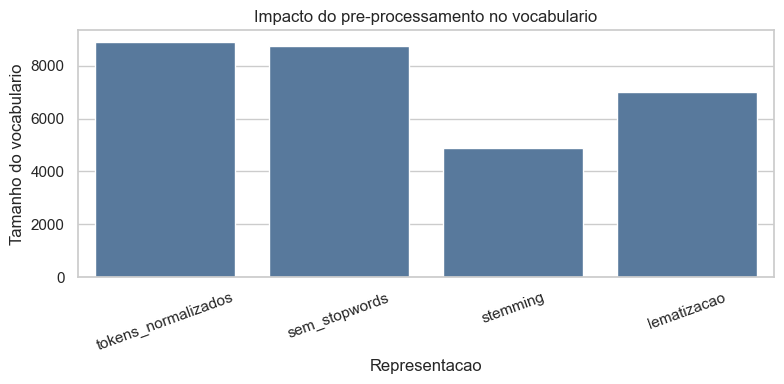

In [8]:
def tamanho_vocabulario(serie_tokens):
    return len(set(itertools.chain.from_iterable(serie_tokens)))


comparacao_vocab = pd.DataFrame({
    'representacao': ['tokens_normalizados', 'sem_stopwords', 'stemming', 'lematizacao'],
    'tamanho_vocabulario': [
        tamanho_vocabulario(df_modelo['tokens']),
        tamanho_vocabulario(df_modelo['tokens_sem_stop']),
        tamanho_vocabulario(df_modelo['stems']),
        tamanho_vocabulario(df_modelo['lemas'])
    ]
})
comparacao_vocab.to_csv(TABLES_DIR / 'comparacao_vocabulario.csv', index=False)
display(comparacao_vocab)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=comparacao_vocab, x='representacao', y='tamanho_vocabulario', ax=ax, color='#4C78A8')
ax.set_title('Impacto do pre-processamento no vocabulario')
ax.set_xlabel('Representacao')
ax.set_ylabel('Tamanho do vocabulario')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'comparacao_vocabulario.png', dpi=150, bbox_inches='tight')
plt.show()

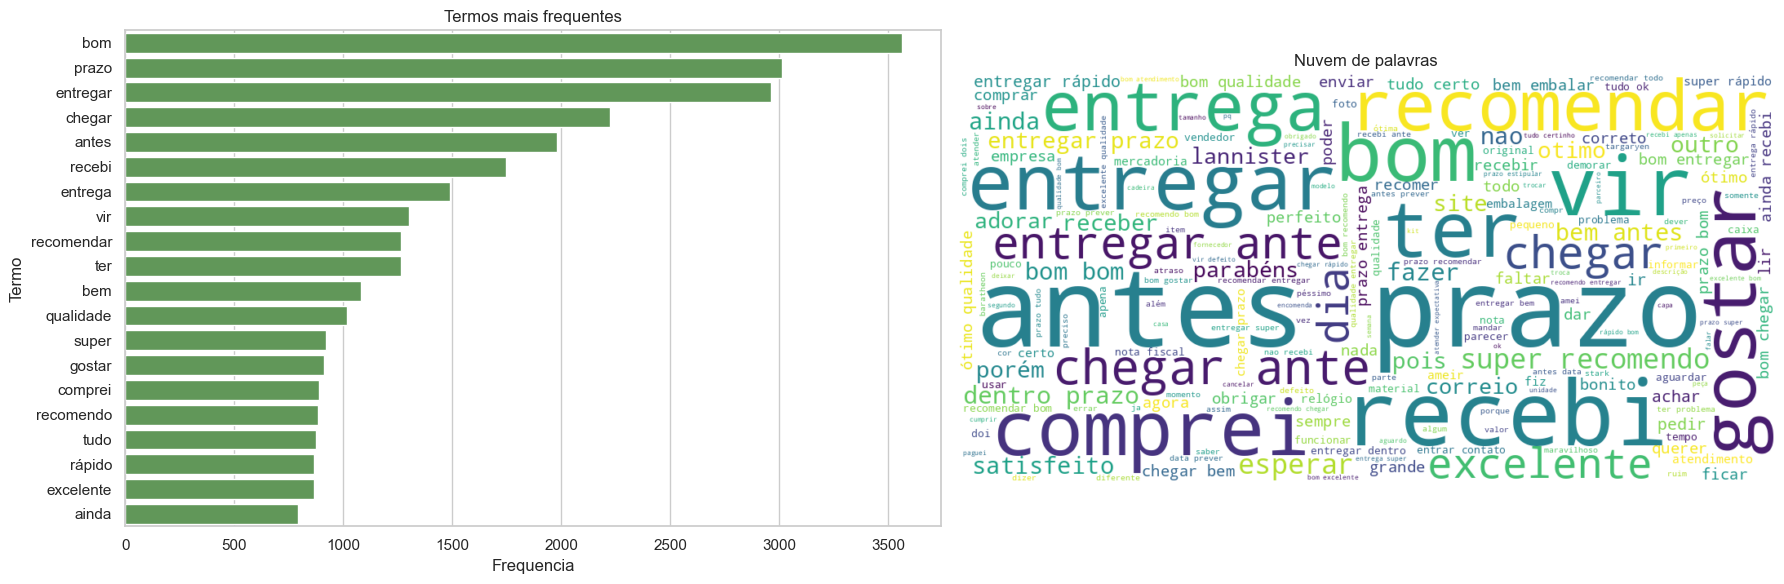

In [9]:
todos_lemas = list(itertools.chain.from_iterable(df_modelo['lemas']))
freq_termos = pd.DataFrame(Counter(todos_lemas).most_common(25), columns=['termo', 'frequencia'])
freq_termos.to_csv(TABLES_DIR / 'termos_mais_frequentes.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.barplot(data=freq_termos.head(20), y='termo', x='frequencia', ax=axes[0], color='#59A14F')
axes[0].set_title('Termos mais frequentes')
axes[0].set_xlabel('Frequencia')
axes[0].set_ylabel('Termo')

texto_wordcloud = ' '.join(df_modelo['texto_lema'])
wordcloud = WordCloud(width=1000, height=500, background_color='white', colormap='viridis').generate(texto_wordcloud)
axes[1].imshow(wordcloud, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Nuvem de palavras')

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'termos_frequentes_wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

,pos,frequencia
0,NOUN,2627
1,VERB,1964
2,ADJ,878
3,ADV,117
4,PROPN,100
5,AUX,65
6,ADP,63
7,DET,52
8,PRON,45
9,SCONJ,26


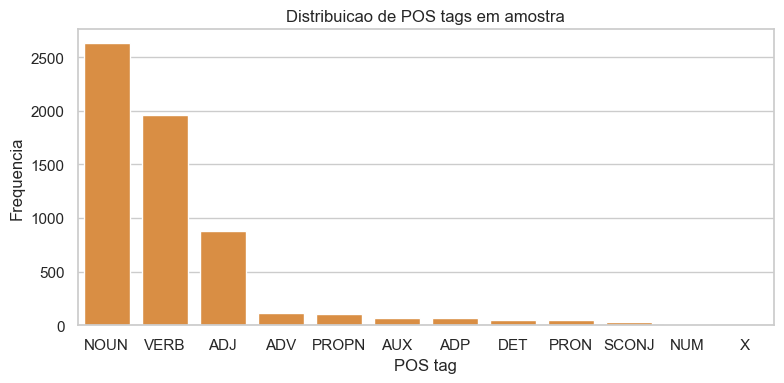

In [10]:
amostra_pos = df_modelo.sample(min(1000, len(df_modelo)), random_state=RANDOM_STATE)
pos_counter = Counter()

for doc in nlp.pipe(amostra_pos['texto_normalizado'].tolist(), batch_size=128):
    for token in doc:
        if token.is_alpha and not token.is_stop:
            pos_counter[token.pos_ or 'NA'] += 1

pos_df = pd.DataFrame(pos_counter.most_common(), columns=['pos', 'frequencia'])
pos_df.to_csv(TABLES_DIR / 'distribuicao_pos_tags.csv', index=False)
display(pos_df.head(15))

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=pos_df.head(12), x='pos', y='frequencia', ax=ax, color='#F28E2B')
ax.set_title('Distribuicao de POS tags em amostra')
ax.set_xlabel('POS tag')
ax.set_ylabel('Frequencia')
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'distribuicao_pos_tags.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Representacao vetorial e busca textual

In [11]:
bow_vectorizer = CountVectorizer(max_features=12000, min_df=3)
tfidf_vectorizer = TfidfVectorizer(max_features=15000, min_df=3, max_df=0.95, ngram_range=(1, 2))

X_bow = bow_vectorizer.fit_transform(df_modelo['texto_lema'])
X_tfidf = tfidf_vectorizer.fit_transform(df_modelo['texto_lema'])

print('Matriz Bag-of-Words:', X_bow.shape)
print('Matriz TF-IDF:', X_tfidf.shape)

Matriz Bag-of-Words: (14903, 2198)
Matriz TF-IDF: (14903, 6113)


In [12]:
def preparar_consulta(consulta):
    texto = normalizar_texto(consulta)
    tokens = remover_stopwords(tokenizar(texto))
    if not tokens:
        return ''
    doc = nlp(' '.join(tokens))
    termos = []
    for token in doc:
        termo = (token.lemma_ or token.text).lower().strip()
        if termo.isalpha() and len(termo) > 1 and termo not in stopwords_total:
            termos.append(termo)
    return ' '.join(termos)


def buscar_documentos(consulta, vectorizer, matriz_tfidf, df_base, top_n=5):
    consulta_processada = preparar_consulta(consulta)
    consulta_vec = vectorizer.transform([consulta_processada])
    scores = cosine_similarity(consulta_vec, matriz_tfidf).ravel()
    indices = scores.argsort()[::-1][:top_n]
    resultado = df_base.iloc[indices][['review_score', 'sentimento', 'texto']].copy()
    resultado['score'] = scores[indices]
    resultado.insert(0, 'consulta_processada', consulta_processada)
    return resultado


consultas = ['entrega atrasada', 'produto chegou quebrado', 'recebi antes do prazo']
resultados_busca = []

for consulta in consultas:
    print(f'Consulta: {consulta}')
    resultado = buscar_documentos(consulta, tfidf_vectorizer, X_tfidf, df_modelo, top_n=5)
    resultado.insert(0, 'consulta_original', consulta)
    resultados_busca.append(resultado)
    display(resultado)

pd.concat(resultados_busca, ignore_index=True).to_csv(TABLES_DIR / 'resultados_busca_textual.csv', index=False)

Consulta: entrega atrasada


,consulta_original,consulta_processada,review_score,sentimento,texto,score
4071,entrega atrasada,entregar atrasar,1,negativo,Entrega atrasada.,1.000000
11395,entrega atrasada,entregar atrasar,1,negativo,entrega muito atrasada.,1.000000
159,entrega atrasada,entregar atrasar,1,negativo,Entrega atrasada Ainda não recebi o produto...,0.833039
9405,entrega atrasada,entregar atrasar,1,negativo,Entrega atrasada Estou aguardando a entrega qu...,0.733276
13175,entrega atrasada,entregar atrasar,1,negativo,entrega atrasada o prazo terminou e nao recebi...,0.679177


Consulta: produto chegou quebrado


,consulta_original,consulta_processada,review_score,sentimento,texto,score
3006,produto chegou quebrado,chegar quebrar,1,negativo,chegou quebrado,1.000000
4011,produto chegou quebrado,chegar quebrar,1,negativo,O produto chegou quebrado.,1.000000
2308,produto chegou quebrado,chegar quebrar,1,negativo,O produto chegou quebrado,1.000000
3810,produto chegou quebrado,chegar quebrar,1,negativo,o produto chegou quebrado. estou aguardando co...,0.704935
5804,produto chegou quebrado,chegar quebrar,1,negativo,Produto quebrado Produto quebrado,0.570214


Consulta: recebi antes do prazo


,consulta_original,consulta_processada,review_score,sentimento,texto,score
8141,recebi antes do prazo,recebi antes prazo,5,positivo,Recebi antes do prazo.,1.0
9069,recebi antes do prazo,recebi antes prazo,5,positivo,Recebi antes do prazo,1.0
9132,recebi antes do prazo,recebi antes prazo,5,positivo,Recebi antes do prazo,1.0
4404,recebi antes do prazo,recebi antes prazo,4,positivo,Recebi antes do prazo....,1.0
4580,recebi antes do prazo,recebi antes prazo,3,neutro,Recebi antes do prazo.,1.0


## 5. Classificacao supervisionada

O campo `review_score` e convertido em tres classes: negativo, neutro e positivo. Naive Bayes e usado como baseline; Regressao Logistica e SVM Linear sao modelos simples e fortes para TF-IDF.

In [13]:
X = df_modelo['texto_lema']
y = df_modelo['sentimento']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

modelos = {
    'Naive Bayes': MultinomialNB(),
    'Regressao Logistica': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
    'SVM Linear': LinearSVC(class_weight='balanced', random_state=RANDOM_STATE)
}

metricas = []
modelos_treinados = {}

for nome, clf in modelos.items():
    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=15000, min_df=3, max_df=0.95, ngram_range=(1, 2))),
        ('clf', clf)
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    metricas.append({
        'modelo': nome,
        'accuracy': report['accuracy'],
        'precision_macro': report['macro avg']['precision'],
        'recall_macro': report['macro avg']['recall'],
        'f1_macro': report['macro avg']['f1-score'],
        'f1_weighted': report['weighted avg']['f1-score']
    })
    modelos_treinados[nome] = pipeline
    print('\n' + nome)
    print(classification_report(y_test, y_pred, zero_division=0))

metricas_df = pd.DataFrame(metricas).sort_values('f1_macro', ascending=False)
metricas_df.to_csv(TABLES_DIR / 'metricas_classificacao.csv', index=False)
display(metricas_df)

melhor_nome = metricas_df.iloc[0]['modelo']
melhor_modelo = modelos_treinados[melhor_nome]
joblib.dump(melhor_modelo, MODELS_DIR / 'modelo_classificacao_sentimento.joblib')
print(f'Melhor modelo por F1 macro: {melhor_nome}')


Naive Bayes
              precision    recall  f1-score   support

    negativo       0.73      0.85      0.79       975
      neutro       0.40      0.01      0.01       304
    positivo       0.88      0.94      0.91      2447

    accuracy                           0.84      3726
   macro avg       0.67      0.60      0.57      3726
weighted avg       0.81      0.84      0.81      3726




Regressao Logistica
              precision    recall  f1-score   support

    negativo       0.73      0.79      0.76       975
      neutro       0.20      0.32      0.24       304
    positivo       0.94      0.83      0.88      2447

    accuracy                           0.78      3726
   macro avg       0.62      0.65      0.63      3726
weighted avg       0.83      0.78      0.80      3726




SVM Linear
              precision    recall  f1-score   support

    negativo       0.74      0.81      0.77       975
      neutro       0.21      0.20      0.20       304
    positivo       0.92      0.89      0.90      2447

    accuracy                           0.81      3726
   macro avg       0.62      0.63      0.63      3726
weighted avg       0.81      0.81      0.81      3726



,modelo,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
1,Regressao Logistica,0.781535,0.622954,0.649757,0.629726,0.799787
2,SVM Linear,0.813473,0.623463,0.632151,0.627235,0.813079
0,Naive Bayes,0.838969,0.673120,0.597211,0.570148,0.805392


Melhor modelo por F1 macro: Regressao Logistica


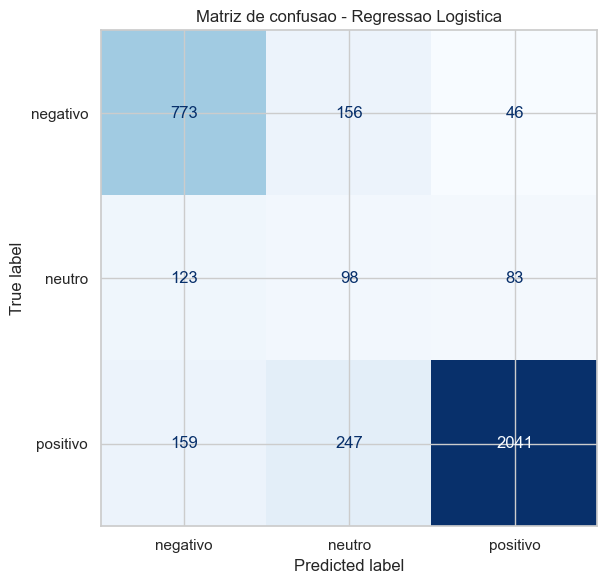

In [14]:
y_pred_melhor = melhor_modelo.predict(X_test)
labels = ['negativo', 'neutro', 'positivo']
cm = confusion_matrix(y_test, y_pred_melhor, labels=labels)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Matriz de confusao - {melhor_nome}')
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'matriz_confusao_melhor_modelo.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Modelagem de topicos com NMF

In [15]:
N_TOPICOS = 6
topic_vectorizer = TfidfVectorizer(max_features=8000, min_df=5, max_df=0.90)
X_topics = topic_vectorizer.fit_transform(df_modelo['texto_lema'])

nmf = NMF(n_components=N_TOPICOS, random_state=RANDOM_STATE, init='nndsvda', max_iter=400)
W = nmf.fit_transform(X_topics)
H = nmf.components_
termos_topicos = np.array(topic_vectorizer.get_feature_names_out())


def termos_principais_topico(componentes, termos, top_n=12):
    linhas = []
    for topico_idx, pesos in enumerate(componentes):
        indices = pesos.argsort()[::-1][:top_n]
        for ordem, idx in enumerate(indices, start=1):
            linhas.append({
                'topico': topico_idx,
                'ordem': ordem,
                'termo': termos[idx],
                'peso': pesos[idx]
            })
    return pd.DataFrame(linhas)


topicos_df = termos_principais_topico(H, termos_topicos, top_n=12)
topicos_df.to_csv(TABLES_DIR / 'topicos_nmf_termos.csv', index=False)
display(topicos_df.head(30))

df_modelo['topico_nmf'] = W.argmax(axis=1)
distribuicao_topicos = pd.crosstab(df_modelo['topico_nmf'], df_modelo['sentimento'], normalize='index')
distribuicao_topicos.to_csv(TABLES_DIR / 'distribuicao_topicos_por_sentimento.csv')
display(distribuicao_topicos)

,topico,ordem,termo,peso
0,0,1,bom,5.948484
1,0,2,qualidade,0.145053
2,0,3,recomendo,0.133746
3,0,4,gostar,0.103357
4,0,5,atendimento,0.099222
5,0,6,entrega,0.078752
6,0,7,preço,0.076827
7,0,8,tudo,0.068344
8,0,9,material,0.045682
9,0,10,vendedor,0.038905


sentimento,negativo,neutro,positivo
topico_nmf,,,
0,0.047552,0.092750,0.859699
1,0.125417,0.059373,0.815210
2,0.147280,0.055347,0.797373
3,0.232755,0.067769,0.699476
4,0.048128,0.021390,0.930481
5,0.498962,0.112243,0.388795


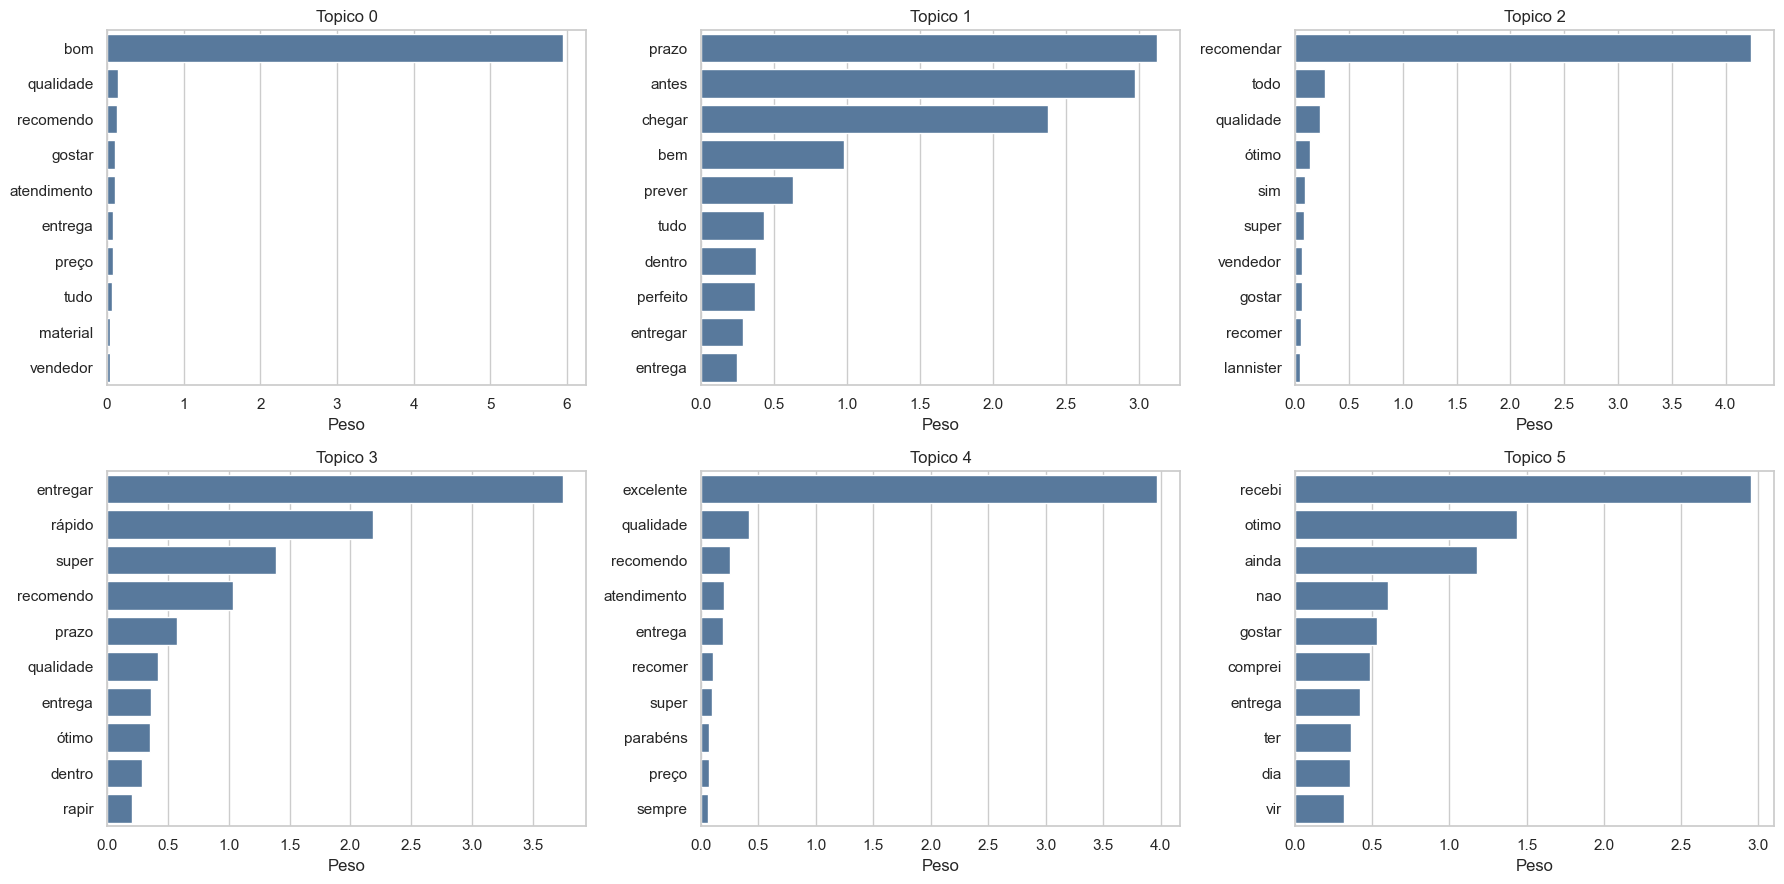

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.ravel()

for topico in range(N_TOPICOS):
    dados = topicos_df[topicos_df['topico'] == topico].head(10)
    sns.barplot(data=dados, y='termo', x='peso', ax=axes[topico], color='#4C78A8')
    axes[topico].set_title(f'Topico {topico}')
    axes[topico].set_xlabel('Peso')
    axes[topico].set_ylabel('')

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'topicos_nmf_termos.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. NER, termos de dominio e grafo de conhecimento

Como avaliacoes de e-commerce costumam ser curtas e nem sempre contem entidades nomeadas formais, o grafo combina entidades extraidas por spaCy com termos de dominio definidos por regras simples.

In [17]:
amostra_ner = df_modelo.sample(min(NER_SAMPLE_SIZE, len(df_modelo)), random_state=RANDOM_STATE)
entidades = []

if SPACY_MODEL_OK and 'ner' in nlp.pipe_names:
    for idx, doc in zip(amostra_ner.index, nlp.pipe(amostra_ner['texto'].tolist(), batch_size=64)):
        for ent in doc.ents:
            texto_entidade = ent.text.strip()
            if len(texto_entidade) > 2:
                entidades.append({
                    'documento_idx': idx,
                    'entidade': texto_entidade,
                    'label': ent.label_,
                    'sentimento': df_modelo.loc[idx, 'sentimento']
                })
else:
    print('NER nao disponivel porque o modelo pt_core_news_sm nao foi carregado.')

entidades_df = pd.DataFrame(entidades)
entidades_df.to_csv(TABLES_DIR / 'entidades_spacy_amostra.csv', index=False)

if not entidades_df.empty:
    display(entidades_df['label'].value_counts().rename_axis('label').reset_index(name='frequencia'))
    display(entidades_df['entidade'].value_counts().head(20).rename_axis('entidade').reset_index(name='frequencia'))
else:
    print('Nenhuma entidade encontrada na amostra.')

,label,frequencia
0,LOC,220
1,MISC,171
2,PER,149
3,ORG,62


,entidade,frequencia
0,Gostei,25
1,Ótimo,24
2,Comprei,21
3,Super,21
4,Recomendo,14
5,super,12
6,PRODUTO,11
7,Amei,11
8,Parabéns,11
9,Entrega,10


In [18]:
padroes_dominio = {
    'entrega': r'\bentreg\w*\b',
    'prazo': r'\bprazo\w*\b',
    'atraso': r'\batras\w*\b',
    'produto': r'\bprodut\w*\b',
    'qualidade': r'\bqualidad\w*\b',
    'defeito': r'\bdefeit\w*\b',
    'embalagem': r'\bembalag\w*\b',
    'troca': r'\btroc\w*\b',
    'reembolso': r'\breembols\w*\b',
    'atendimento': r'\batend\w*\b',
    'vendedor': r'\bvendedor\w*\b',
    'frete': r'\bfrete\w*\b',
    'correio': r'\bcorreio\w*\b',
    'transportadora': r'\btransportador\w*\b',
    'rastreio': r'\brastre\w*\b',
    'demora': r'\bdemor\w*\b',
    'quebrado': r'\bquebrad\w*\b',
    'avariado': r'\bavariad\w*\b',
    'errado': r'\berrad\w*\b',
    'incompleto': r'\bincomplet\w*\b',
    'recomendo': r'\brecomend\w*\b',
    'excelente': r'\bexcelent\w*\b',
    'bom': r'\bbom\b|\bboa\b',
    'ruim': r'\bruim\b',
    'satisfeito': r'\bsatisfeit\w*\b',
    'problema': r'\bproblem\w*\b',
    'cancelamento': r'\bcancel\w*\b',
    'devolucao': r'\bdevolu\w*\b',
    'nota fiscal': r'\bnota\s+fiscal\b',
    'pagamento': r'\bpagament\w*\b'
}

padroes_compilados = {termo: re.compile(padrao, flags=re.IGNORECASE) for termo, padrao in padroes_dominio.items()}


def extrair_termos_dominio(texto_normalizado):
    return [termo for termo, padrao in padroes_compilados.items() if padrao.search(texto_normalizado)]


df_modelo['termos_dominio'] = df_modelo['texto_normalizado'].apply(extrair_termos_dominio)
termos_extraidos = list(itertools.chain.from_iterable(df_modelo['termos_dominio']))
termos_dominio_df = pd.DataFrame(Counter(termos_extraidos).most_common(), columns=['termo', 'frequencia'])
termos_dominio_df.to_csv(TABLES_DIR / 'termos_dominio_frequencia.csv', index=False)
display(termos_dominio_df.head(25))

,termo,frequencia
0,produto,6501
1,entrega,4033
2,prazo,2944
3,bom,2409
4,recomendo,2363
5,qualidade,990
6,excelente,821
7,atendimento,519
8,satisfeito,511
9,correio,383


In [19]:
G = nx.Graph()

for sentimento in sorted(df_modelo['sentimento'].unique()):
    G.add_node(sentimento, tipo='sentimento')

for termo in padroes_dominio.keys():
    G.add_node(termo, tipo='termo')


def incrementar_aresta(grafo, origem, destino, peso=1):
    if grafo.has_edge(origem, destino):
        grafo[origem][destino]['weight'] += peso
    else:
        grafo.add_edge(origem, destino, weight=peso)


for _, row in df_modelo.iterrows():
    termos = sorted(set(row['termos_dominio']))[:8]
    if not termos:
        continue
    sentimento = row['sentimento']
    for termo in termos:
        incrementar_aresta(G, sentimento, termo)
    for termo_a, termo_b in itertools.combinations(termos, 2):
        incrementar_aresta(G, termo_a, termo_b)

centralidade_grau = nx.degree_centrality(G)
centralidade_intermediacao = nx.betweenness_centrality(G, weight='weight', normalized=True)

centralidade_df = pd.DataFrame({
    'no': list(G.nodes()),
    'tipo': [G.nodes[no].get('tipo', 'termo') for no in G.nodes()],
    'grau': [G.degree(no) for no in G.nodes()],
    'degree_centrality': [centralidade_grau[no] for no in G.nodes()],
    'betweenness_centrality': [centralidade_intermediacao[no] for no in G.nodes()]
}).sort_values(['degree_centrality', 'grau'], ascending=False)

centralidade_df.to_csv(TABLES_DIR / 'centralidade_grafo.csv', index=False)
nx.write_graphml(G, GRAPHS_DIR / 'grafo_conhecimento_olist.graphml')

print(f'Nos: {G.number_of_nodes()} | Arestas: {G.number_of_edges()}')
display(centralidade_df.head(15))

Nos: 33 | Arestas: 443


,no,tipo,grau,degree_centrality,betweenness_centrality
3,entrega,termo,32,1.00000,0.000000
4,prazo,termo,32,1.00000,0.000000
6,produto,termo,32,1.00000,0.000000
15,correio,termo,32,1.00000,0.011257
23,recomendo,termo,32,1.00000,0.014897
25,bom,termo,31,0.96875,0.000000
0,negativo,sentimento,30,0.93750,0.000000
1,neutro,sentimento,30,0.93750,0.000000
9,embalagem,termo,30,0.93750,0.119993
12,atendimento,termo,30,0.93750,0.006805


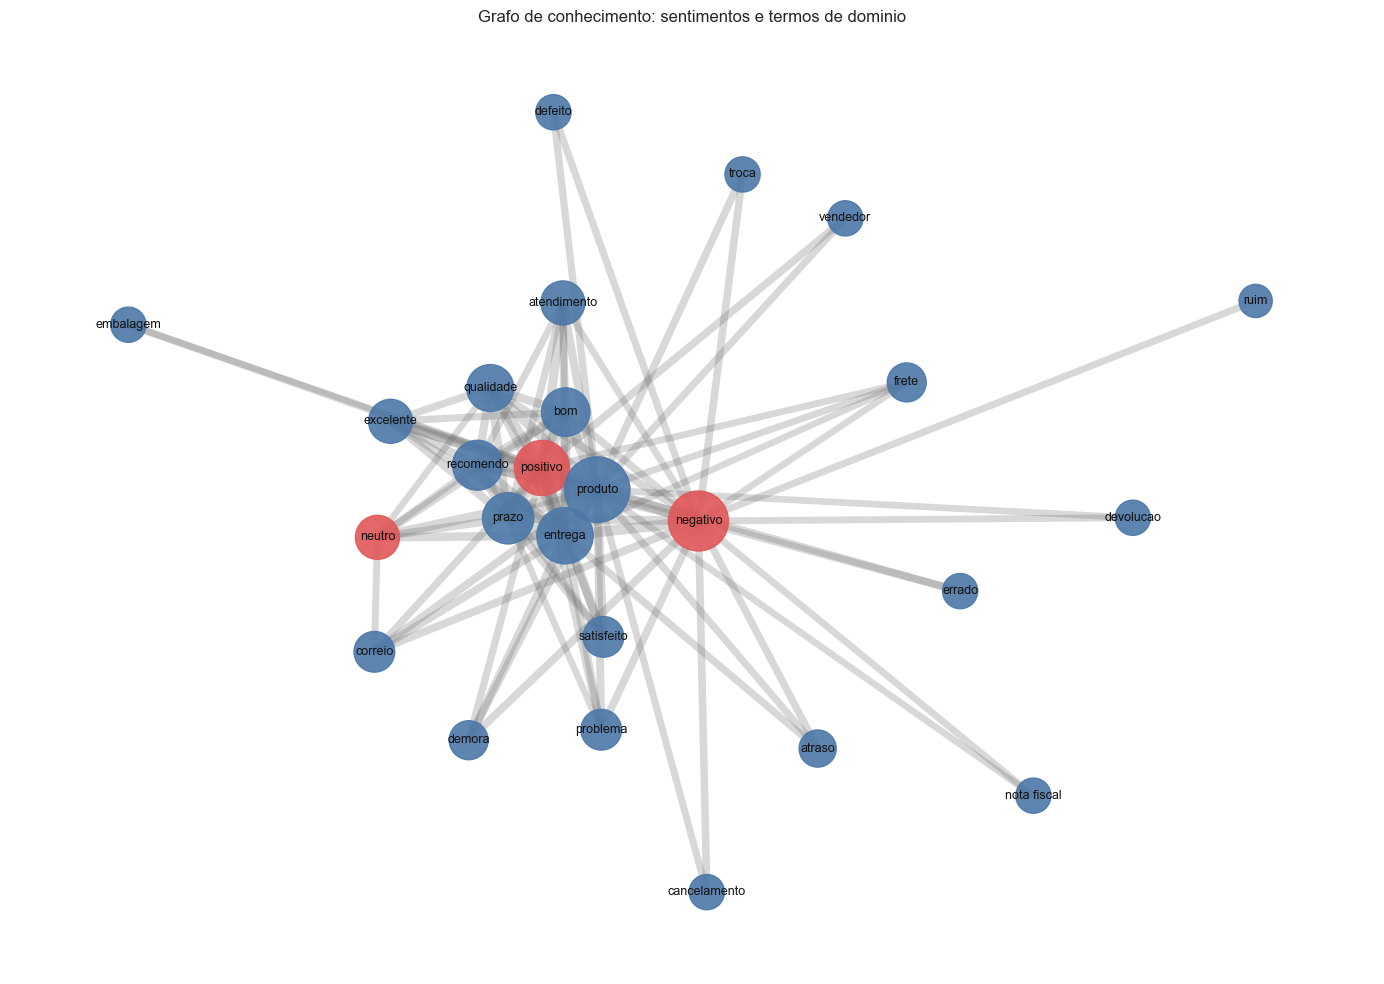

In [20]:
top_edges = sorted(G.edges(data=True), key=lambda item: item[2].get('weight', 1), reverse=True)[:90]
H_vis = nx.Graph()
for origem, destino, dados in top_edges:
    H_vis.add_node(origem, **G.nodes[origem])
    H_vis.add_node(destino, **G.nodes[destino])
    H_vis.add_edge(origem, destino, **dados)

pos = nx.spring_layout(H_vis, seed=RANDOM_STATE, k=0.8)
node_colors = ['#E15759' if H_vis.nodes[no].get('tipo') == 'sentimento' else '#4C78A8' for no in H_vis.nodes()]
node_sizes = [500 + 1800 * nx.degree_centrality(H_vis).get(no, 0) for no in H_vis.nodes()]
edge_widths = [0.5 + np.log1p(dados.get('weight', 1)) for _, _, dados in H_vis.edges(data=True)]

fig, ax = plt.subplots(figsize=(14, 10))
nx.draw_networkx_nodes(H_vis, pos, node_color=node_colors, node_size=node_sizes, alpha=0.9, ax=ax)
nx.draw_networkx_edges(H_vis, pos, width=edge_widths, alpha=0.25, edge_color='#666666', ax=ax)
nx.draw_networkx_labels(H_vis, pos, font_size=9, font_color='#111111', ax=ax)
ax.set_title('Grafo de conhecimento: sentimentos e termos de dominio')
ax.axis('off')
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'grafo_conhecimento.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Sintese interpretativa

Pontos a preencher apos a execucao completa:

- Os comentarios positivos tendem a concentrar termos ligados a entrega no prazo, recomendacao e boa experiencia.
- Os comentarios negativos tendem a concentrar termos ligados a atraso, defeito, troca, devolucao, atendimento e problemas com entrega.
- O modelo supervisionado deve ser avaliado principalmente por F1 macro, pois as classes podem ser desbalanceadas.
- A classe neutra costuma ser mais dificil, porque notas 3 podem misturar satisfacao parcial e reclamacoes moderadas.
- O grafo ajuda a identificar quais termos estao mais conectados aos sentimentos e quais temas aparecem juntos.

Limitacoes principais:

- Muitos comentarios sao curtos, o que reduz contexto semantico.
- O rotulo de sentimento e inferido pela nota, nao por anotacao manual.
- Avaliacoes de e-commerce possuem poucas entidades nomeadas formais, por isso a extracao foi complementada com termos de dominio.
- O projeto usa apenas a tabela local de reviews; outras tabelas da Olist poderiam enriquecer a analise.